In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data/season2023_Austin.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          1014 non-null   int64  
 1   Time                1014 non-null   object 
 2   Driver              1014 non-null   object 
 3   DriverNumber        1014 non-null   int64  
 4   LapTime             1014 non-null   object 
 5   LapNumber           1014 non-null   float64
 6   Stint               1014 non-null   float64
 7   PitOutTime          40 non-null     object 
 8   PitInTime           39 non-null     object 
 9   Sector1Time         994 non-null    object 
 10  Sector2Time         1014 non-null   object 
 11  Sector3Time         1014 non-null   object 
 12  Sector1SessionTime  990 non-null    object 
 13  Sector2SessionTime  1014 non-null   object 
 14  Sector3SessionTime  1014 non-null   object 
 15  SpeedI1             897 non-null    float64
 16  SpeedI

In [4]:
df.head()

,Unnamed: 0,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0,0 days 01:04:25,VER,1,0 days 00:01:45.537000,1.0,1.0,NaN,NaN,NaN,...,True,Red Bull Racing,0 days 01:02:39.217000,NaN,1,5.0,NaN,NaN,False,False
1,1,0 days 01:06:08.009000,VER,1,0 days 00:01:43.009000,2.0,1.0,NaN,NaN,0 days 00:00:28.137000,...,True,Red Bull Racing,0 days 01:04:25,NaN,1,5.0,NaN,NaN,False,True
2,2,0 days 01:07:50.709000,VER,1,0 days 00:01:42.700000,3.0,1.0,NaN,NaN,0 days 00:00:28.030000,...,True,Red Bull Racing,0 days 01:06:08.009000,NaN,1,5.0,NaN,NaN,False,True
3,3,0 days 01:09:33.332000,VER,1,0 days 00:01:42.623000,4.0,1.0,NaN,NaN,0 days 00:00:27.874000,...,True,Red Bull Racing,0 days 01:07:50.709000,NaN,1,5.0,NaN,NaN,False,True
4,4,0 days 01:11:15.483000,VER,1,0 days 00:01:42.151000,5.0,1.0,NaN,NaN,0 days 00:00:27.760000,...,True,Red Bull Racing,0 days 01:09:33.332000,NaN,1,4.0,NaN,NaN,False,True


In [5]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
df.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:04:25,VER,1,0 days 00:01:45.537000,1.0,1.0,NaN,NaN,NaN,0 days 00:00:41.862000,...,True,Red Bull Racing,0 days 01:02:39.217000,NaN,1,5.0,NaN,NaN,False,False
1,0 days 01:06:08.009000,VER,1,0 days 00:01:43.009000,2.0,1.0,NaN,NaN,0 days 00:00:28.137000,0 days 00:00:41.118000,...,True,Red Bull Racing,0 days 01:04:25,NaN,1,5.0,NaN,NaN,False,True
2,0 days 01:07:50.709000,VER,1,0 days 00:01:42.700000,3.0,1.0,NaN,NaN,0 days 00:00:28.030000,0 days 00:00:40.871000,...,True,Red Bull Racing,0 days 01:06:08.009000,NaN,1,5.0,NaN,NaN,False,True
3,0 days 01:09:33.332000,VER,1,0 days 00:01:42.623000,4.0,1.0,NaN,NaN,0 days 00:00:27.874000,0 days 00:00:41.035000,...,True,Red Bull Racing,0 days 01:07:50.709000,NaN,1,5.0,NaN,NaN,False,True
4,0 days 01:11:15.483000,VER,1,0 days 00:01:42.151000,5.0,1.0,NaN,NaN,0 days 00:00:27.760000,0 days 00:00:40.607000,...,True,Red Bull Racing,0 days 01:09:33.332000,NaN,1,4.0,NaN,NaN,False,True


In [6]:
# ---- PARSE TIME COLUMNS ----
# FastF1 stores times as strings like "0 days 00:01:45.537000"
# pd.to_timedelta parses that format directly; .dt.total_seconds() gives a float
# float seconds is what you want for plotting lap time on a y-axis

# PitIn/PitOut are mostly NaN (only set on pit laps)
# we don't convert them to seconds, we just need to know if they EXIST to filter pit laps
# so leave them as-is; .isna() works on the raw strings fine

df['LapTime'] = pd.to_timedelta(df['LapTime']).dt.total_seconds()

In [7]:
print(df.shape)

(1014, 31)


In [8]:
# ---- FILTER 1: ACCURACY FLAG ----
# FastF1's built-in sanity check: sector sum matches lap time, not first lap after SC, etc.
# NOT a guarantee of quality — docs explicitly warn this. but it's a cheap first pass.

df = df[df['IsAccurate'] == True]

In [9]:
print(df.shape)


(919, 31)


In [10]:
# ---- FILTER 2: GREEN FLAG ONLY ----
# TrackStatus == 1 means green flag racing.
# anything else (2=yellow, 4=SC, 5=red, 6/7=VSC, etc.) contaminates lap times
# because drivers aren't pushing. degradation analysis needs clean racing laps only.

df = df[df['TrackStatus'] == 1]

In [11]:
# ---- FILTER 3: NO PIT LAPS ----
# in-laps (PitInTime not null) = driver slowing to enter pits
# out-laps (PitOutTime not null) = driver leaving pits on cold tires
# both are garbage for tire degradation analysis because the lap time is
# dominated by the pit sequence, not tire performance.
# IsAccurate catches most of these via sector-sum mismatch, but not all.

df = df[df['PitInTime'].isna() & df['PitOutTime'].isna()]

In [12]:
print(df.shape)

(912, 31)


In [13]:
# ---- SANITY CHECK ----
# at this point every row should be: accurate, green flag, pure racing lap
# the unit of analysis for tire degradation is the STINT:
# one continuous run on one set of tires = one (Driver, Stint) group
# each stint should have exactly ONE compound. verify that's true.
stint_compounds = df.groupby(['Driver', 'Stint'])['Compound'].nunique()
assert stint_compounds.max() == 1, "some stint has multiple compounds, data is weird"
print(f"Clean stints: {len(stint_compounds)}")

Clean stints: 55


In [14]:
# TODO TOMORROW:
# plot LapTime (y, seconds) vs TyreLife (x, laps on current set)
# one point per lap, color by Compound
# fit a linear regression per (Driver, Stint) and draw the trend line
# that IS the degradation curve. that's the MVP chart.

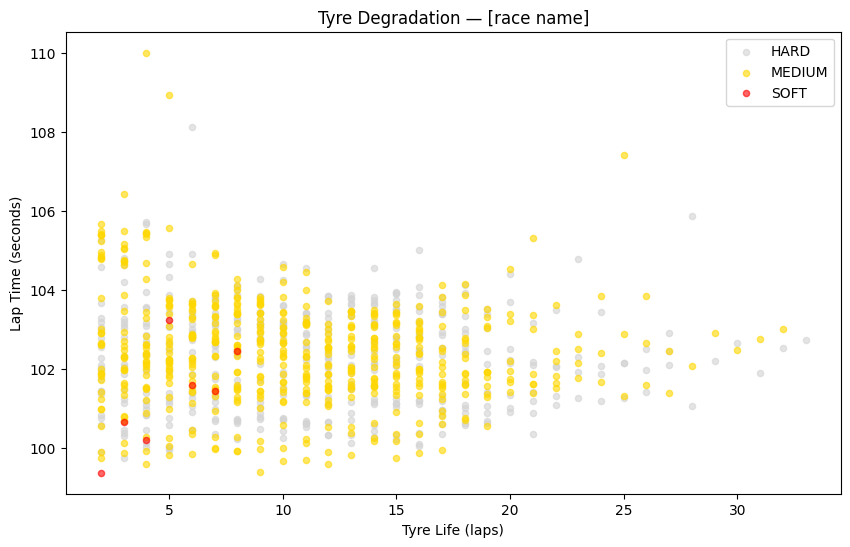

In [15]:
import matplotlib.pyplot as plt

# assuming df is your cleaned dataframe from 3 days ago
compound_colors = {'SOFT': 'red', 'MEDIUM': 'gold', 'HARD': 'lightgray',
                   'INTERMEDIATE': 'green', 'WET': 'blue'}

fig, ax = plt.subplots(figsize=(10, 6))
for compound, group in df.groupby('Compound'):
    ax.scatter(group['TyreLife'], group['LapTime'],
               c=compound_colors.get(compound, 'black'),
               label=compound, alpha=0.6, s=20)

ax.set_xlabel('Tyre Life (laps)')
ax.set_ylabel('Lap Time (seconds)')
ax.set_title('Tyre Degradation — [race name]')
ax.legend()
plt.show()

      LapNumber  TyreLife  LapTime Compound
982        25.0       2.0  102.103     HARD
983        26.0       3.0  102.055     HARD
984        27.0       4.0  101.398     HARD
985        28.0       5.0  101.397     HARD
986        29.0       6.0  101.386     HARD
987        30.0       7.0  101.750     HARD
988        31.0       8.0  101.715     HARD
989        32.0       9.0  101.721     HARD
990        33.0      10.0  101.329     HARD
991        34.0      11.0  101.328     HARD
992        35.0      12.0  101.273     HARD
993        36.0      13.0  101.501     HARD
994        37.0      14.0  101.101     HARD
995        38.0      15.0  101.025     HARD
996        39.0      16.0  102.800     HARD
997        40.0      17.0  101.190     HARD
998        41.0      18.0  101.652     HARD
999        42.0      19.0  101.410     HARD
1000       43.0      20.0  102.150     HARD
1001       44.0      21.0  101.422     HARD
1002       45.0      22.0  101.305     HARD
1003       46.0      23.0  101.2

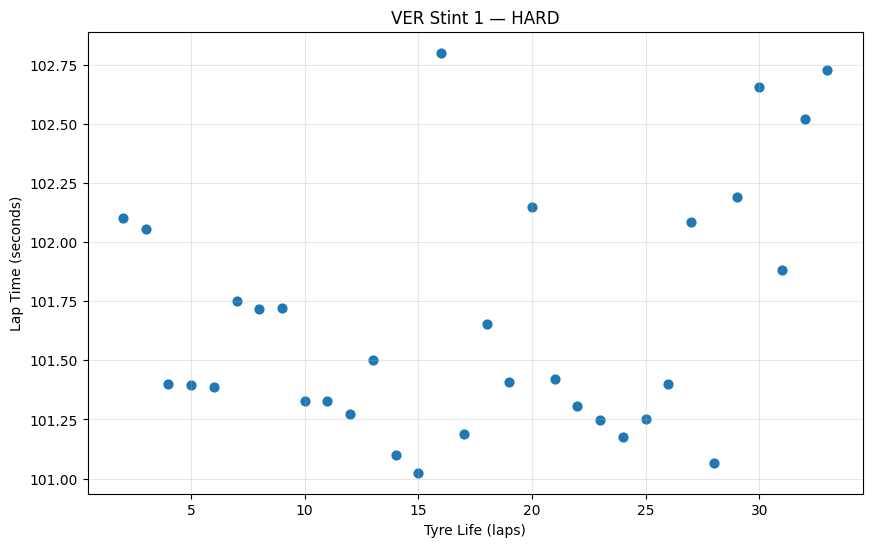

In [16]:
# pick one driver, one stint
subset = df[(df['Driver'] == 'LEC') & (df['Stint'] == 2.0)]

print(subset[['LapNumber', 'TyreLife', 'LapTime', 'Compound']])
print(f"Compound: {subset['Compound'].unique()}")
print(f"Laps in stint: {len(subset)}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(subset['TyreLife'], subset['LapTime'], s=40)
ax.set_xlabel('Tyre Life (laps)')
ax.set_ylabel('Lap Time (seconds)')
ax.set_title(f"VER Stint 1 — {subset['Compound'].iloc[0]}")
ax.grid(True, alpha=0.3)
plt.show()

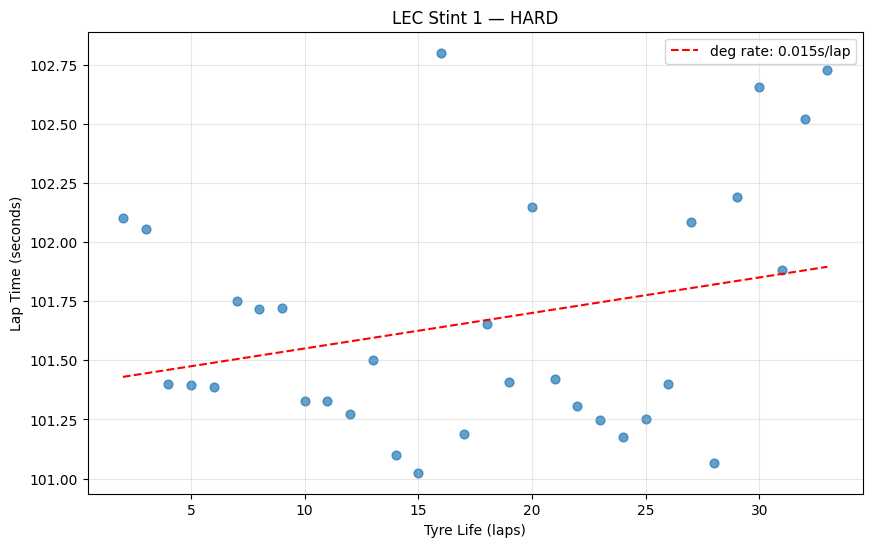

In [17]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(subset['TyreLife'], subset['LapTime'], s=40, alpha=0.7)

# linear fit
x = subset['TyreLife'].values
y = subset['LapTime'].values
slope, intercept = np.polyfit(x, y, 1)
ax.plot(x, slope*x + intercept, 'r--', label=f'deg rate: {slope:.3f}s/lap')

ax.set_xlabel('Tyre Life (laps)')
ax.set_ylabel('Lap Time (seconds)')
ax.set_title(f"LEC Stint 1 — HARD")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [18]:
import pandas as pd
import glob
import os

def clean_race(filepath):
    """Take raw FastF1 CSV, return cleaned dataframe with race metadata."""
    df = pd.read_csv(filepath)
    df = df.drop(columns=['Unnamed: 0'], errors='ignore')

    # parse lap time
    df['LapTime'] = pd.to_timedelta(df['LapTime']).dt.total_seconds()

    # filters: is accurate, green flag conditions, no pit laps
    df = df[df['IsAccurate'] == True]
    df = df[df['TrackStatus'] == 1]
    df = df[df['PitInTime'].isna() & df['PitOutTime'].isna()]

    # tag with race identity from filename
    fname = os.path.basename(filepath).replace('.csv', '')
    parts = fname.split('_')
    df['Season'] = parts[0]      # e.g. "season25"
    df['Race'] = parts[1]        # e.g. "Monaco"

    # keep only the important columns
    keep = ['Season', 'Race', 'Driver', 'Team', 'LapNumber', 'Stint',
            'TyreLife', 'Compound', 'FreshTyre', 'LapTime', 'Position']
    df = df[keep]

    return df

# loop every CSV in your scrape folder
csv_files = glob.glob('data/*.csv')   # fix this path
print(f"Found {len(csv_files)} race files")

cleaned = []
for fp in csv_files:
    try:
        cdf = clean_race(fp)
        cleaned.append(cdf)
        print(f"  {os.path.basename(fp)}: {len(cdf)} clean laps")
    except Exception as e:
        print(f"  FAILED {os.path.basename(fp)}: {e}")

master = pd.concat(cleaned, ignore_index=True)
print(f"\nMaster dataframe: {master.shape}")
print(master.head())

master.to_csv('clean.csv', index=False)

Found 70 race files
  season2024_Silverstone.csv: 850 clean laps
  season2025_Zandvoort.csv: 1005 clean laps
  season2024_Baku.csv: 853 clean laps
  season2024_Spielberg.csv: 1250 clean laps
  season2025_Baku.csv: 796 clean laps
  season2023_Sakhir.csv: 889 clean laps
  season2025_Austin.csv: 926 clean laps
  season2023_Suzuka.csv: 686 clean laps
  season2024_Las Vegas.csv: 826 clean laps
  season2025_Miami Gardens.csv: 861 clean laps
  season2024_Lusail.csv: 679 clean laps
  season2023_Las Vegas.csv: 644 clean laps
  season2024_Monaco.csv: 1171 clean laps
  season2024_Miami.csv: 934 clean laps
  season2023_Spielberg.csv: 1168 clean laps
  season2023_Silverstone.csv: 802 clean laps
  season2025_Montréal.csv: 1163 clean laps
  season2023_Monaco.csv: 1259 clean laps
  season2023_Barcelona.csv: 1207 clean laps
  season2023_Miami.csv: 1078 clean laps
  season2023_Lusail.csv: 806 clean laps
  season2024_Melbourne.csv: 852 clean laps
  season2025_Jeddah.csv: 810 clean laps
  season2025_Silve

In [19]:
print(master['Compound'].value_counts(dropna=False))
print(master['Season'].unique())
print(master.groupby(['Season','Race']).size().describe())

Compound
HARD            32156
MEDIUM          23409
SOFT             6912
INTERMEDIATE     3057
NaN               470
WET                45
Name: count, dtype: int64
['season2024' 'season2025' 'season2023']
count      70.000000
mean      943.557143
std       185.319672
min       441.000000
25%       807.000000
50%       926.500000
75%      1077.000000
max      1354.000000
dtype: float64


In [21]:
# fuel correction: F1 cars burn ~1.6 kg of fuel per lap.
# fuel sensitivity ~0.035 s/kg of pace.
# net effect: each lap of fuel burned = ~0.055s faster pace.
# we ADD this back to lap times to remove the fuel-burn confounder,
# leaving (mostly) pure tire degradation in the regression slope.
FUEL_CORRECTION_PER_LAP = 0.055  # seconds per lap (consensus value)

master['LapTimeFuelCorrected'] = master['LapTime'] + FUEL_CORRECTION_PER_LAP * master['LapNumber']

print(master[['LapNumber', 'LapTime', 'LapTimeFuelCorrected']].head())

   LapNumber  LapTime  LapTimeFuelCorrected
0        2.0   91.420                91.530
1        3.0   91.716                91.881
2        4.0   91.988                92.208
3        5.0   91.677                91.952
4        6.0   91.746                92.076


In [22]:
import numpy as np

def compute_stint_slopes(df, min_laps=5):
    """Per (Season, Race, Driver, Stint), fit linear deg rate."""
    rows = []
    grouped = df.groupby(['Season', 'Race', 'Driver', 'Stint'])
    for (season, race, driver, stint), g in grouped:
        if len(g) < min_laps:
            continue  # skip stints too short to fit
        if g['Compound'].nunique() != 1:
            continue  # skip weird stints with mixed compound (shouldn't happen but defensive)
        x = g['TyreLife'].values
        y = g['LapTime'].values
        slope, intercept = np.polyfit(x, y, 1)
        rows.append({
            'Season': season,
            'Race': race,
            'Driver': driver,
            'Team': g['Team'].iloc[0],
            'Stint': stint,
            'Compound': g['Compound'].iloc[0],
            'NumLaps': len(g),
            'DegRate': slope,
            'Intercept': intercept,
            'MeanLapTime': y.mean(),
        })
    return pd.DataFrame(rows)

stints = compute_stint_slopes(master)
print(f"Total stints: {len(stints)}")
print(stints.head(10))
print(stints.groupby('Compound')['DegRate'].describe())

LinAlgError: SVD did not converge in Linear Least Squares

In [23]:
def compute_stint_slopes(df, min_laps=8, y_col='LapTimeFuelCorrected'):
    rows = []
    grouped = df.groupby(['Season', 'Race', 'Driver', 'Stint'])
    for (season, race, driver, stint), g in grouped:
        if len(g) < min_laps:
            continue
        if g['Compound'].nunique() != 1:
            continue

        x = g['TyreLife'].values
        y = g[y_col].values   # <-- now uses fuel-corrected times

        if np.isnan(x).any() or np.isnan(y).any():
            continue
        if len(np.unique(x)) < 2:
            continue

        try:
            slope, intercept = np.polyfit(x, y, 1)
        except np.linalg.LinAlgError:
            continue

        rows.append({
            'Season': season, 'Race': race, 'Driver': driver,
            'Team': g['Team'].iloc[0], 'Stint': stint,
            'Compound': g['Compound'].iloc[0], 'NumLaps': len(g),
            'DegRate': slope, 'Intercept': intercept,
            'MeanLapTime': g['LapTime'].mean(),  # uncorrected for display
        })
    return pd.DataFrame(rows)

stints = compute_stint_slopes(master)
stints = stints[stints['DegRate'].abs() < 1.0]
stints = stints[~stints['Compound'].isin(['INTERMEDIATE', 'WET'])]  # drop wet stuff

print(f"Total stints: {len(stints)}")
print(stints.groupby('Compound')['DegRate'].describe())
print()
print(stints.groupby(['Race', 'Compound'])['DegRate'].median().unstack())

Total stints: 2791
           count      mean       std       min       25%       50%       75%  \
Compound                                                                       
HARD      1227.0  0.047892  0.074496 -0.751963  0.015006  0.051710  0.084720   
MEDIUM    1179.0  0.047084  0.116411 -0.913167  0.005115  0.057198  0.096292   
SOFT       385.0  0.073119  0.139817 -0.850457  0.031220  0.078659  0.132723   

               max  
Compound            
HARD      0.554409  
MEDIUM    0.767218  
SOFT      0.660217  

Compound               HARD    MEDIUM      SOFT
Race                                           
Austin             0.048395  0.045946  0.048954
Baku              -0.002702 -0.013786       NaN
Barcelona          0.072612  0.072458  0.097940
Budapest           0.084421  0.052169 -0.024929
Imola              0.064490  0.086586       NaN
Jeddah            -0.009111  0.010499  0.104360
Las Vegas          0.008938  0.023730       NaN
Lusail             0.015498 -0.016226  0.0

In [24]:
print(stints.groupby(['Race', 'Compound'])['DegRate'].median().unstack())

Compound               HARD    MEDIUM      SOFT
Race                                           
Austin             0.048395  0.045946  0.048954
Baku              -0.002702 -0.013786       NaN
Barcelona          0.072612  0.072458  0.097940
Budapest           0.084421  0.052169 -0.024929
Imola              0.064490  0.086586       NaN
Jeddah            -0.009111  0.010499  0.104360
Las Vegas          0.008938  0.023730       NaN
Lusail             0.015498 -0.016226  0.064600
Marina Bay         0.061973  0.012972  0.008011
Melbourne          0.022975  0.063547       NaN
Mexico City        0.042998  0.068701  0.072450
Miami              0.025347  0.013488  0.010557
Miami Gardens      0.045378  0.075190       NaN
Monaco             0.031426  0.019285  0.064260
Montréal           0.033706  0.016649       NaN
Monza              0.047845  0.032145       NaN
Sakhir             0.096875  0.099559  0.143599
Shanghai           0.068119  0.124009  0.171727
Silverstone        0.043041  0.026156  0

In [25]:
stints.to_csv('stint_slopes_corrected.csv', index=False)
master.to_csv('master_clean.csv', index=False)

In [26]:
stints[stints['Race']=='Silverstone']

,Season,Race,Driver,Team,Stint,Compound,NumLaps,DegRate,Intercept,MeanLapTime
650,season2023,Silverstone,ALB,Williams,1.0,MEDIUM,30,0.005773,94.422707,93.610467
651,season2023,Silverstone,ALB,Williams,2.0,SOFT,14,0.031077,93.854582,91.895929
652,season2023,Silverstone,ALO,Aston Martin,1.0,MEDIUM,30,0.004158,94.280673,93.445933
653,season2023,Silverstone,ALO,Aston Martin,2.0,SOFT,14,0.049413,93.677881,91.941286
654,season2023,Silverstone,BOT,Alfa Romeo,1.0,HARD,30,-0.016789,95.328550,94.144033
...,...,...,...,...,...,...,...,...,...,...
2682,season2025,Silverstone,PIA,McLaren,3.0,MEDIUM,8,-0.335083,95.703083,91.192625
2686,season2025,Silverstone,SAI,Williams,3.0,MEDIUM,9,-0.545600,98.856089,92.396889
2688,season2025,Silverstone,STR,Aston Martin,4.0,SOFT,8,0.030440,95.396321,92.957125
2690,season2025,Silverstone,TSU,Red Bull Racing,3.0,MEDIUM,8,-0.913167,101.979583,93.431500


In [27]:
 stints[stints['Race']=='Silverstone'].groupby(['Season','Compound']).agg({'DegRate':'median', 'NumLaps':'mean', 'Driver':'count'})

DegRate    NumLaps  Driver
Season     Compound                             
season2023 HARD      0.048718  17.500000       6
           MEDIUM    0.016609  25.588235      17
           SOFT      0.024490  15.600000      15
season2024 HARD      0.019000  13.000000       3
           MEDIUM    0.228606  20.772727      22
           SOFT      0.095484  12.916667      12
season2025 MEDIUM   -0.380258   8.700000      10
           SOFT     -0.266667   8.333333       3

In [28]:
# tag wet-affected races
wet_races = master[master['Compound'].isin(['INTERMEDIATE','WET'])][['Season','Race']].drop_duplicates()
wet_set = set(zip(wet_races['Season'], wet_races['Race']))

stints['WetAffected'] = stints.apply(
    lambda r: (r['Season'], r['Race']) in wet_set, axis=1
)

# show the impact
clean_stints = stints[~stints['WetAffected']]
print(f"All stints: {len(stints)}, dry-only: {len(clean_stints)}")

# recompute the table with dry races only
print(clean_stints.groupby(['Race','Compound'])['DegRate'].median().unstack())

All stints: 2791, dry-only: 2644
Compound               HARD    MEDIUM      SOFT
Race                                           
Austin             0.048395  0.045946  0.048954
Baku              -0.002702 -0.013786       NaN
Barcelona          0.072612  0.072458  0.097940
Budapest           0.084421  0.052169 -0.024929
Imola              0.064490  0.086586       NaN
Jeddah            -0.009111  0.010499  0.104360
Las Vegas          0.008938  0.023730       NaN
Lusail             0.015498 -0.016226  0.064600
Marina Bay         0.061973  0.012972  0.008011
Melbourne          0.022975  0.063547       NaN
Mexico City        0.042998  0.068701  0.072450
Miami              0.025347  0.013488  0.010557
Miami Gardens      0.045378  0.075190       NaN
Monaco             0.016783 -0.005719  0.047571
Montréal           0.038230  0.058215       NaN
Monza              0.047845  0.032145       NaN
Sakhir             0.096875  0.099559  0.143599
Shanghai           0.068119  0.124009  0.171727
Silvers

In [29]:
clean_stints.to_csv('stint_slopes_final.csv', index=False)
master.to_csv('master_clean_final.csv', index=False)